# Data Cleaning and Preprocessing using Python

## Project Overview

Data cleaning is one of the most important steps in the data analysis process. Real-world datasets often contain missing values, duplicate records, inconsistent formatting, incorrect data types, and outliers. These issues can reduce the accuracy of analysis and machine learning models.

In this project, a messy employee dataset is cleaned using Python and Pandas. Various preprocessing techniques are applied to transform the raw data into a clean, analysis-ready dataset.

## Objectives

- Load and inspect the dataset.
- Generate a data quality report.
- Handle missing values using appropriate techniques.
- Remove duplicate records.
- Standardize inconsistent formatting.
- Detect and handle outliers.
- Correct incorrect data types.
- Compare the dataset before and after cleaning.
- Export the cleaned dataset as a CSV file.

# Import Required Libraries

The following libraries are used for data manipulation, numerical operations, and data visualization during the data cleaning process.

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


In [29]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("messy_employee_dataset.csv")

print("✅ Dataset Loaded Successfully!")


original_df = df.copy()

df.head()

✅ Dataset Loaded Successfully!


,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


# Dataset Overview

This section provides a quick overview of the dataset, including the number of rows, columns, data types, and sample records.

In [30]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1020
Columns : 12


In [31]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   str    
 1   First_Name         1020 non-null   str    
 2   Last_Name          1020 non-null   str    
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   str    
 5   Status             1020 non-null   str    
 6   Join_Date          1020 non-null   str    
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   str    
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   str    
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(8)
memory usage: 165.7 KB


In [33]:
# First Five Records

df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [34]:
# Descriptive Statistics

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,1020,1020,EMP1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First_Name,1020,8,Frank,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last_Name,1020,8,Brown,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,809.0,NaN,NaN,NaN,32.484549,5.65686,25.0,25.0,30.0,40.0,40.0
Department_Region,1020,36,HR-Florida,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,1020,3,Pending,356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Join_Date,1020,760,6/10/2024,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,996.0,NaN,NaN,NaN,85155.056396,19873.727918,50047.32,68392.4875,85547.87,100974.0275,119971.65
Email,1020,64,grace.brown@example.com,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phone,1020.0,NaN,NaN,NaN,-4942252959.221569,2817326049.742002,-9994973202.0,-7341991816.5,-4943996508.5,-2520390678.75,-3896086.0


# Data Quality Report

Before cleaning the dataset, it is important to assess its overall quality. This includes identifying missing values, duplicate records, incorrect data types, and potential anomalies. The report provides a baseline for comparing the dataset before and after the cleaning process.

In [35]:
# ==========================================
# Data Quality Report
# ==========================================

print("Dataset Shape :", df.shape)
print("\n")

print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

Dataset Shape : (1020, 12)


Missing Values
Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

Duplicate Rows : 0

Data Types
Employee_ID              str
First_Name               str
Last_Name                str
Age                  float64
Department_Region        str
Status                   str
Join_Date                str
Salary               float64
Email                    str
Phone                  int64
Performance_Score        str
Remote_Work             bool
dtype: object


# Missing Value Analysis

Missing values can negatively impact data analysis and machine learning models. In this section, the number of missing values in each column is identified before selecting an appropriate treatment strategy.

In [36]:
# Missing Values

missing_values = df.isnull().sum().to_frame(name="Missing Values")

missing_values

,Missing Values
Employee_ID,0
First_Name,0
Last_Name,0
Age,211
Department_Region,0
Status,0
Join_Date,0
Salary,24
Email,0
Phone,0


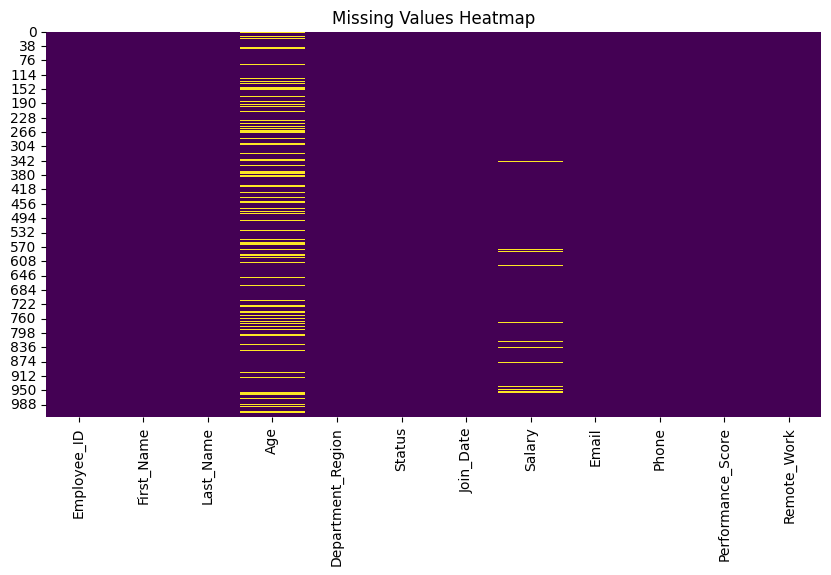

In [37]:
# Visualize Missing Values

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

# Missing Value Handling

Missing values were handled using appropriate statistical techniques based on the nature of each column.

### Strategy Used

- **Age**: Missing values are replaced using the **median** because age may contain outliers and the median is less affected by extreme values.
- **Salary**: Missing values are replaced using the **mean** since salary is a continuous numerical variable with relatively few missing values.

These strategies help preserve the dataset while minimizing information loss.

In [38]:
# ==========================================
# Handle Missing Values
# ==========================================

# Fill missing Age with Median
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill missing Salary with Mean
df["Salary"].fillna(df["Salary"].mean(), inplace=True)

print("✅ Missing Values Handled Successfully!")

✅ Missing Values Handled Successfully!


In [39]:
# Verify Missing Values

df.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [40]:
print(df.columns)

Index(['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region',
       'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score',
       'Remote_Work'],
      dtype='str')


In [41]:
print(df["Age"].dtype)
print(df["Salary"].dtype)

print(df[["Age", "Salary"]].head(10))

float64
float64
    Age     Salary
0  25.0   59767.65
1   NaN   65304.66
2   NaN   88145.90
3  25.0   69450.99
4  25.0  109324.61
5  40.0   88642.84
6   NaN   96288.43
7  30.0   94497.91
8  35.0  115565.82
9   NaN   76561.88


In [42]:
print(df[df["Age"].isnull()].head())

print(df[df["Salary"].isnull()].head())

   Employee_ID First_Name Last_Name  Age  Department_Region   Status  \
1      EMP1001        Bob     Brown  NaN      Finance-Texas   Active   
2      EMP1002      Alice     Jones  NaN       Admin-Nevada  Pending   
6      EMP1006      Frank     Jones  NaN       Admin-Nevada   Active   
9      EMP1009    Charlie   Johnson  NaN    DevOps-New York   Active   
11     EMP1011      David     Davis  NaN  DevOps-California   Active   

    Join_Date    Salary                        Email       Phone  \
1   7/10/2020  65304.66        bob.brown@example.com -1898471390   
2   12/7/2023  88145.90      alice.jones@example.com -5596363211   
6    4/3/2020  96288.43      frank.jones@example.com -4518376063   
9    8/4/2022  76561.88  charlie.johnson@example.com -8156985699   
11   9/4/2023  84946.19      david.davis@example.com -1238296576   

   Performance_Score  Remote_Work  
1          Excellent         True  
2               Good         True  
6               Good        False  
9          Exc

In [43]:
print(df["Age"].dtype)
print(df["Salary"].dtype)

float64
float64


In [44]:
print("Age Median:", df["Age"].median())
print("Salary Mean:", df["Salary"].mean())

Age Median: 30.0
Salary Mean: 85155.05639558233


In [45]:
print("Before Filling")
print("Age Missing:", df["Age"].isnull().sum())
print("Salary Missing:", df["Salary"].isnull().sum())

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

print("\nAfter Filling")
print("Age Missing:", df["Age"].isnull().sum())
print("Salary Missing:", df["Salary"].isnull().sum())

Before Filling
Age Missing: 211
Salary Missing: 24

After Filling
Age Missing: 0
Salary Missing: 0


In [46]:
df.isnull().sum()

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department_Region    0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

# Duplicate Record Detection

Duplicate records may introduce bias and redundancy into the dataset. Identifying and removing duplicate rows improves data quality and ensures accurate analysis.

In [47]:
# Check duplicate rows

duplicates_before = df.duplicated().sum()

print("Duplicate Rows Before Cleaning :", duplicates_before)

Duplicate Rows Before Cleaning : 0


In [48]:
# Remove duplicate rows

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicate Rows After Cleaning :", duplicates_after)

Duplicate Rows After Cleaning : 0


# Data Standardization

Data standardization ensures consistency across categorical variables and date formats.

The following standardization steps are performed:

- Convert Join_Date to datetime format.
- Remove leading/trailing spaces from text columns.
- Standardize text formatting using title case.

In [49]:
# Convert date column

df["Join_Date"] = pd.to_datetime(df["Join_Date"])

# Standardize text columns

text_columns = [
    "First_Name",
    "Last_Name",
    "Department_Region",
    "Status",
    "Performance_Score"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.title()

print("Data Standardization Completed")

Data Standardization Completed


# Data Type Verification

The data types of all columns are verified to ensure they match their intended formats before analysis.

In [50]:
print(df.dtypes)

Employee_ID                     str
First_Name                      str
Last_Name                       str
Age                         float64
Department_Region               str
Status                          str
Join_Date            datetime64[us]
Salary                      float64
Email                           str
Phone                         int64
Performance_Score               str
Remote_Work                    bool
dtype: object


# Outlier Detection using IQR

Outliers are detected in numerical columns using the Interquartile Range (IQR) method. Extreme values are capped to reduce their impact while preserving the overall dataset.

In [51]:
numeric_columns = ["Age", "Salary"]

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers Handled Successfully")

Outliers Handled Successfully


# Before vs. After Data Cleaning Summary

The table below compares the dataset before and after the data cleaning process. It highlights the improvements made in terms of missing values, duplicate records, row count, and data type accuracy.

In [52]:
# ==========================================
# Before vs After Summary
# ==========================================

summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        original_df.shape[0],
        original_df.shape[1],
        original_df.isnull().sum().sum(),
        original_df.duplicated().sum()
    ],
    "After Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Total Rows,1020,1020
1,Total Columns,12,12
2,Missing Values,235,0
3,Duplicate Rows,0,0


# Save Cleaned Dataset

After completing all cleaning operations, the cleaned dataset is exported as a new CSV file for future analysis.

In [53]:
# Save Cleaned Dataset

df.to_csv("Cleaned_Messy_Employee_Dataset.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


# Conclusion

The messy employee dataset has been successfully cleaned and transformed into an analysis-ready dataset.

### Cleaning Tasks Performed

- Missing values handled using Median and Mean imputation.
- Duplicate records identified and removed.
- Text formatting standardized.
- Date column converted to datetime format.
- Outliers detected and capped using the IQR method.
- Data types verified and corrected.
- Before vs After comparison generated.
- Cleaned dataset exported to CSV.

The resulting dataset is now reliable for visualization, statistical analysis, and machine learning applications.